In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score,roc_auc_score
import pickle as p

In [37]:
df = pd.read_csv("Dataset.csv")
df.sample(3)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
13301,39,Private,286789,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
3168,40,Private,116103,Some-college,10,Separated,Craft-repair,Unmarried,White,Male,4934,0,47,United-States,>50K
7770,34,Private,146161,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,>50K


In [56]:
print(df.isnull().sum())
print(df.describe())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64
                age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.00000

In [39]:
X = df.drop(["income","fnlwgt"],axis=1)
y = df["income"].map({"<=50K":0,">50K":1})
print(X.sample(3))
print(y.sample(3))
num_cols = X.select_dtypes(include=["number","float"]).columns.to_list()
cat_cols = X.select_dtypes(include=["string","object"]).columns.to_list()
X.shape

       age workclass     education  education.num      marital.status  \
410     52   Private  Some-college             10  Married-civ-spouse   
19810   22   Private       HS-grad              9       Never-married   
10835   22   Private  Some-college             10       Never-married   

            occupation   relationship   race     sex  capital.gain  \
410    Exec-managerial        Husband  White    Male             0   
19810     Adm-clerical  Not-in-family  White  Female             0   
10835     Tech-support  Not-in-family  White  Female             0   

       capital.loss  hours.per.week native.country  
410            1977              50  United-States  
19810             0              40  United-States  
10835             0              43  United-States  
26332    0
27249    0
21342    0
Name: income, dtype: int64


(32561, 13)

In [73]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 42,test_size=0.2,stratify=y)
X_train.shape

(26048, 13)

In [81]:
preprocessor = ColumnTransformer(
    [
        ("Encoding",OneHotEncoder(handle_unknown="ignore"),cat_cols),
        ("Non-encoding", "passthrough", num_cols)
    ],remainder="passthrough"
)

In [82]:
pipeline = Pipeline(
    [
        ("preprocessing",preprocessor),
        ("model",RandomForestClassifier(random_state = 42))
    ]
)

In [83]:
param_grid = {
    "model__n_estimators" : [400,500],
    "model__criterion" : ["gini","entropy"],
    "model__bootstrap" : [True,False],
    "model__max_depth" : [20,30,None],
    "model__min_samples_split" : [5,10],
    "model__min_samples_leaf" : [1,2]
}
grid = GridSearchCV(pipeline,param_grid,cv=7,n_jobs=-1,verbose=2,scoring="roc_auc")
grid.fit(X_train,y_train)

Fitting 7 folds for each of 96 candidates, totalling 672 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__bootstrap': [True, False], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [20, 30, ...], 'model__min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",7
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [84]:
best_pipeline = grid.best_estimator_
print("Best Pipeline",best_pipeline)
print("Best Parameters",grid.best_params_)
print("Best Score",grid.best_score_)
y_pred = best_pipeline.predict(X_test)

Best Pipeline Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Encoding',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country']),
                                                 ('Non-encoding', 'passthrough',
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week'])])),
            

Accuracy Score of the model is: 86.0%
ROC-AUC: 91.0
Classification Report
               precision    recall  f1-score   support

           0       0.88      0.95      0.91      4945
           1       0.78      0.58      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513



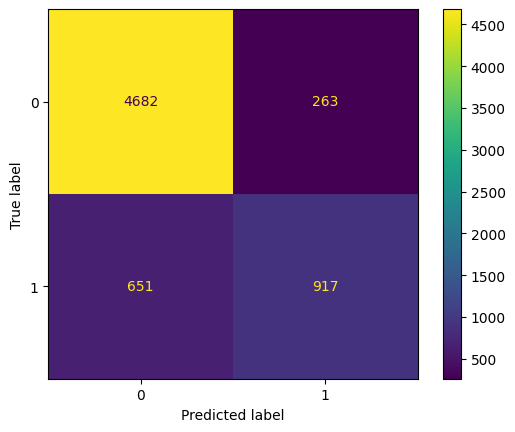

In [85]:
print(f"Accuracy Score of the model is: {round(accuracy_score(y_test,y_pred),2)*100}%")
y_prob = best_pipeline.predict_proba(X_test)[:, 1]
print("ROC-AUC:",round(roc_auc_score(y_test, y_prob),2)*100)
print("Classification Report\n",classification_report(y_test,y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

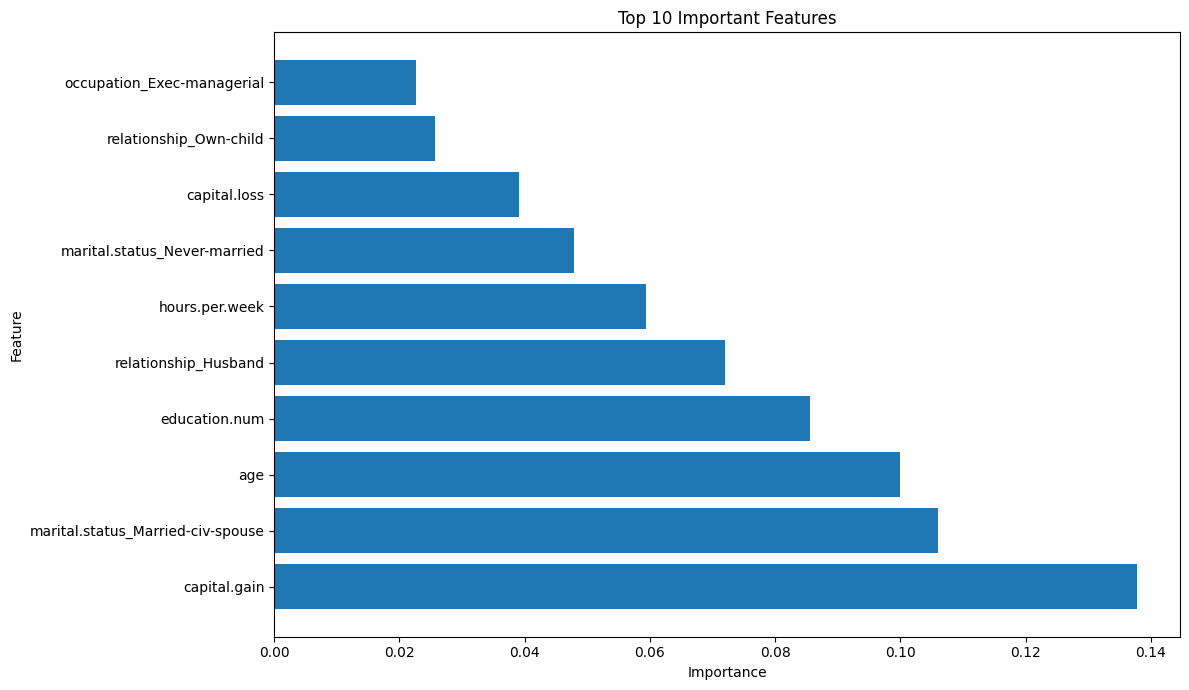

In [89]:
feature_names = best_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()
feature_names = [
    feature.replace("Encoding__", "")
           .replace("Non-encoding__", "")
    for feature in feature_names
]
importances = best_pipeline.named_steps[
    "model"
].feature_importances_
importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)
top10 = importance_df.nlargest(10, "Importance")
top10 = top10.sort_values("Importance")
plt.figure(figsize=(12,7))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [87]:
p.dump(preprocessor,open("preprocessor.pkl","wb"))
p.dump(best_pipeline,open("model.pkl","wb"))